# Évaluation de la transcription (HTR) — corpus Scoledit

Ce notebook analyse la fidélité de LECTURE d'un modèle sur l'écriture manuscrite
d'enfants (corpus Scoledit), indépendamment du codage des fautes. On compare la
transcription du modèle à la transcription de référence humaine.

| § | Analyse |
|---|--------|
| 1 | Synthèse : CER / WER moyens, taux d'échec |
| 2 | Distribution du CER par copie |
| 3 | CER brut vs normalisé (part des erreurs = accents/casse) |
| 4 | Copies les plus mal transcrites (à inspecter) |
| 5 | Comparaison visuelle référence / hypothèse mot à mot |

**Prérequis** : avoir lancé
`uv run scripts/run_htr_benchmark.py --config configs/htr_gemma4_scoledit.yaml`
qui produit `data/processed/<RUN>_htr_predictions.jsonl`.

**Rappel méthodologique** : la référence Scoledit préserve les fautes de l'élève.
Un CER de 0 signifie donc que le modèle a reproduit fidèlement le texte de l'élève,
*fautes comprises* — c'est bien la lecture qu'on évalue, pas l'orthographe.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# ════════════ PARAMÈTRES ════════════
RUN_NAME = "htr_gemma4_scoledit"
SCANS_DIR = "s3://projet-production-ecrits-depp/scoledit/scans/CE1/"
# ════════════════════════════════════

BASE = Path("..")
PRED = BASE / f"data/processed/{RUN_NAME}_htr_predictions.jsonl"
df = pd.DataFrame(json.loads(line) for line in open(PRED, encoding="utf-8"))

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
print(f"{len(df)} copies · niveau(x) : {sorted(df['level'].unique())}")

10 copies · niveau(x) : ['CE1']


## 1. Synthèse

In [2]:
ok = df[df["transcrit"]]
# CER/WER micro-pondérés par la longueur de la référence
cer = (ok["cer"] * ok["n_char_ref"]).sum() / ok["n_char_ref"].sum()
wer = (ok["wer"] * ok["n_mots_ref"]).sum() / ok["n_mots_ref"].sum()
cer_n = (ok["cer_normalise"] * ok["n_char_ref"]).sum() / ok["n_char_ref"].sum()
n_echecs = int((~df["transcrit"]).sum())

print(f"CER moyen           : {cer:.1%}")
print(f"WER moyen           : {wer:.1%}")
print(f"CER normalisé       : {cer_n:.1%}  (accents/casse/ponctuation ignorés)")
print(f"Échecs transcription: {n_echecs} / {len(df)}")
print(f"\nInterprétation : {cer_n:.1%} du CER subsiste après normalisation → "
      "c'est la part d'erreurs de lecture 'substantielles' (au-delà des accents/casse).")

CER moyen           : 8.9%
WER moyen           : 26.3%
CER normalisé       : 6.9%  (accents/casse/ponctuation ignorés)
Échecs transcription: 0 / 10

Interprétation : 6.9% du CER subsiste après normalisation → c'est la part d'erreurs de lecture 'substantielles' (au-delà des accents/casse).


## 2. Distribution du CER par copie

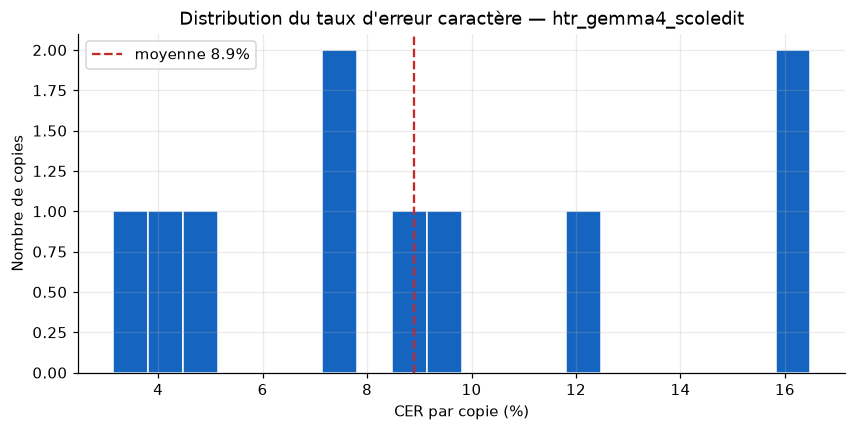

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ok["cer"] * 100, bins=20, color="#1565c0", edgecolor="white")
ax.axvline(cer * 100, color="#c62828", ls="--", label=f"moyenne {cer:.1%}")
ax.set_xlabel("CER par copie (%)")
ax.set_ylabel("Nombre de copies")
ax.set_title(f"Distribution du taux d'erreur caractère — {RUN_NAME}")
ax.legend()
plt.savefig(BASE / f"data/processed/{RUN_NAME}_cer_distribution.png")
plt.show()

## 3. CER brut vs normalisé

L'écart entre les deux mesure la part d'« erreurs » qui ne sont que des différences
d'accents, de casse ou de ponctuation — souvent moins graves qu'une vraie mélecture.

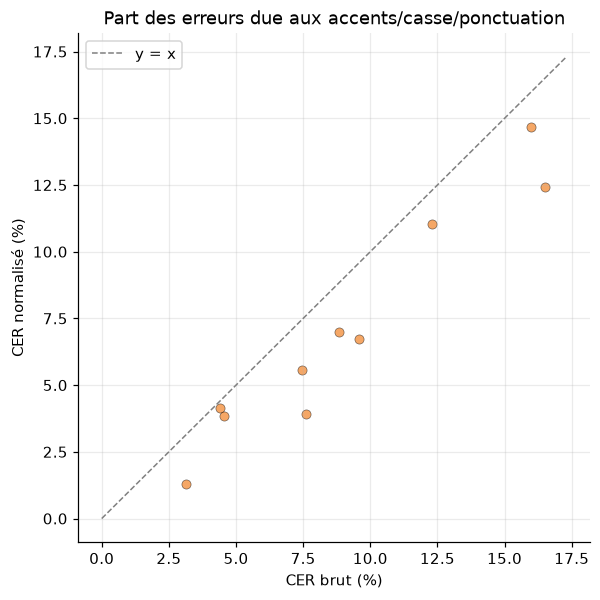

La normalisation réduit le CER de 23% : c'est la part d'écart imputable aux accents/casse/ponctuation.


In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(ok["cer"] * 100, ok["cer_normalise"] * 100, alpha=0.6, color="#ef6c00",
           edgecolors="k", linewidths=0.4)
lim = max(ok["cer"].max(), ok["cer_normalise"].max()) * 105
ax.plot([0, lim], [0, lim], "--", color="grey", lw=1, label="y = x")
ax.set_xlabel("CER brut (%)")
ax.set_ylabel("CER normalisé (%)")
ax.set_title("Part des erreurs due aux accents/casse/ponctuation")
ax.legend()
plt.savefig(BASE / f"data/processed/{RUN_NAME}_cer_brut_vs_normalise.png")
plt.show()

reduction = 1 - cer_n / cer if cer else 0
print(f"La normalisation réduit le CER de {reduction:.0%} : "
      "c'est la part d'écart imputable aux accents/casse/ponctuation.")

## 4. Copies les plus mal transcrites

In [5]:
pires = df.sort_values("cer", ascending=False).head(10)
display(pires[["scan", "cer", "wer", "cer_normalise", "n_mots_ref", "transcrit"]]
        .style.format({"cer": "{:.1%}", "wer": "{:.1%}", "cer_normalise": "{:.1%}"}))

# Export CSV complet
df.sort_values("cer", ascending=False).to_csv(
    BASE / f"data/processed/{RUN_NAME}_htr_par_copie.csv",
    sep=";", decimal=",", encoding="utf-8-sig", index=False)

,scan,cer,wer,cer_normalise,n_mots_ref,transcrit
6,1099a,16.5%,27.3%,12.4%,77,True
9,1101a,16.0%,51.7%,14.7%,29,True
1,102a,12.3%,46.6%,11.0%,58,True
0,100a,9.6%,25.0%,6.7%,44,True
5,1098a,8.8%,20.6%,7.0%,34,True
8,1100a,7.6%,17.6%,3.9%,51,True
7,1099b,7.5%,38.2%,5.6%,34,True
4,107b,4.6%,14.8%,3.8%,54,True
3,107a,4.4%,17.1%,4.2%,70,True
2,103a,3.1%,19.0%,1.3%,63,True


## 5. Comparaison visuelle référence / hypothèse

Pour une copie donnée, affiche côte à côte la transcription de référence (humaine)
et celle du modèle, avec les mots divergents surlignés. Saisir un `scan` à inspecter.

In [6]:
import difflib
from IPython.display import HTML, display

SCAN = pires.iloc[0]["scan"]  # par défaut : la pire copie

row = df[df["scan"] == SCAN].iloc[0]
ref_mots = row["reference"].split()
hyp_mots = row["hypothese"].split()
sm = difflib.SequenceMatcher(a=ref_mots, b=hyp_mots)

def surligne(mots, spans, couleur):
    out = []
    for i, mot in enumerate(mots):
        bg = couleur if i in spans else "transparent"
        out.append(f"<span style='background:{bg};padding:1px 3px;border-radius:3px'>{mot}</span>")
    return " ".join(out)

diff_ref, diff_hyp = set(), set()
for tag, i1, i2, j1, j2 in sm.get_opcodes():
    if tag != "equal":
        diff_ref.update(range(i1, i2))
        diff_hyp.update(range(j1, j2))

html = f"""
<div style='font-family:Georgia,serif;line-height:1.8'>
  <h3>Scan {SCAN} — CER {row['cer']:.1%} · WER {row['wer']:.1%}</h3>
  <p><b>Référence (humaine)</b> :<br>{surligne(ref_mots, diff_ref, '#d7f0d7')}</p>
  <p><b>Transcription du modèle</b> :<br>{surligne(hyp_mots, diff_hyp, '#f7d4d4')}</p>
</div>
"""
display(HTML(html))

## 6. HTML des N pires transcriptions

Génère un fichier HTML autonome affichant, pour chaque copie parmi les N pires,
l'image + la référence humaine + la transcription du modèle avec les mots divergents
surlignés. À ouvrir dans le navigateur (clic droit → Open in browser).

In [7]:
from evaluation_dictee.transcription.visual_diff import report_worst_transcriptions

N_PIRES = 10

out_pires = report_worst_transcriptions(
    predictions_df=df,
    scans_dir=SCANS_DIR,
    output_path=BASE / f"data/processed/htr_pires_{N_PIRES}_{RUN_NAME}.html",
    n=N_PIRES,
)
print(f"Généré : {out_pires}")

Généré : ../data/processed/htr_pires_10_htr_gemma4_scoledit.html


## 7. HTML de N transcriptions aléatoires

Complément indispensable des N pires : donne une vue REPRÉSENTATIVE de la
performance moyenne, plutôt que le seul angle des cas pathologiques.

In [8]:
from evaluation_dictee.transcription.visual_diff import report_random_transcriptions

N_ALEA = 10
SEED = 42

out_random = report_random_transcriptions(
    predictions_df=df,
    scans_dir=SCANS_DIR,
    output_path=BASE / f"data/processed/htr_random_{N_ALEA}_{RUN_NAME}.html",
    n=N_ALEA,
    seed=SEED,
)
print(f"Généré : {out_random}")

Généré : ../data/processed/htr_random_10_htr_gemma4_scoledit.html
